# Robust vs Shortcut Results

Visualizes the Instantiation II (shift-aware) results from `scripts/out/journal/summary_shift.csv`  
and the mask visualization saved at `scripts/out/robust_shortcut_masks.png`.

Run `scripts/run_experiments.py` first to generate the data.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

REPO = Path('/Users/ssuresh/gambit')
CSV  = REPO / 'scripts' / 'out' / 'journal' / 'summary_shift.csv'
MASK_PNG = REPO / 'scripts' / 'out' / 'robust_shortcut_masks.png'

df = pd.read_csv(CSV)
print(f'Game modes: {df["game_mode"].tolist()}')
print(f'Seeds: n={df["n_seeds"].iloc[0]}')
df

Game modes: ['cooperative', 'mixed', 'competitive']
Seeds: n=3


,disjoint_fmt,disjoint_mean,disjoint_std,game_mode,id_ood_gap_fmt,id_ood_gap_mean,id_ood_gap_std,n_seeds,rob_mean_fmt,rob_mean_mean,rob_mean_std,rob_var_fmt,rob_var_mean,rob_var_std,sho_gap_fmt,sho_gap_mean,sho_gap_std,sparse_fmt,sparse_mean,sparse_std
0,1.2802,1.280201,0.492065,cooperative,0.0085,0.008463,0.023932,3,0.0611,0.061116,0.027835,0.0007,0.000730,0.000381,-0.0034,-0.003391,0.010543,3.6013,3.601345,0.516065
1,0.1702,0.170173,0.010218,mixed,0.0202,0.020199,0.025372,3,0.0512,0.051182,0.016884,0.0004,0.000366,0.000186,0.0285,0.028513,0.005997,2.9560,2.955985,0.107767
2,0.1664,0.166367,0.012194,competitive,-0.0020,-0.002001,0.079476,3,0.0298,0.029752,0.006960,0.0002,0.000215,0.000079,0.0469,0.046877,0.014706,2.9159,2.915901,0.128559


## 1. Metrics Table

Column guide:
- **Rob Mean ↑** — robust sufficiency averaged across environments (want high: robust evidence should explain the prediction)
- **Rob Var ↓** — variance of robust sufficiency across environments (want low: robust evidence should be stable)
- **Sho Gap ↑** — shortcut sufficiency on ID minus OOD (want high: shortcut evidence is ID-specific)
- **Disjoint ↓** — overlap between robust and shortcut masks (want low: masks should separate)
- **Sparse ↓** — average mask mass (want low: compact masks)
- **ID-OOD Gap ↑** — quantitative shortcut gap (positive = shortcut is ID-specific)

In [2]:
METRIC_COLS = {
    'rob_mean': 'Rob Mean ↑',
    'rob_var':  'Rob Var ↓',
    'sho_gap':  'Sho Gap ↑',
    'disjoint': 'Disjoint ↓',
    'sparse':   'Sparse ↓',
    'id_ood_gap': 'ID-OOD Gap ↑',
}

n_seeds = df['n_seeds'].iloc[0]
display_rows = []
for _, row in df.iterrows():
    r = {'Game Mode': row['game_mode']}
    for key, label in METRIC_COLS.items():
        mu  = row.get(f'{key}_mean', float('nan'))
        std = row.get(f'{key}_std', 0.0)
        if n_seeds > 1 and std > 0:
            r[label] = f'{mu:.4f} ± {std:.4f}'
        else:
            r[label] = f'{mu:.4f}'
    display_rows.append(r)

table = pd.DataFrame(display_rows).set_index('Game Mode')

# Warn if all signal metrics are zero (untrained model)
all_zero = all(
    abs(row.get('rob_mean_mean', 0)) < 1e-4 and abs(row.get('sho_gap_mean', 0)) < 1e-4
    for _, row in df.iterrows()
)
if all_zero:
    print('⚠️  Rob Mean and Sho Gap are ~0 — backbone model is untrained.')
    print('   Re-run with a trained checkpoint to get meaningful signal.')

table

,Rob Mean ↑,Rob Var ↓,Sho Gap ↑,Disjoint ↓,Sparse ↓,ID-OOD Gap ↑
Game Mode,,,,,,
cooperative,0.0611 ± 0.0278,0.0007 ± 0.0004,-0.0034 ± 0.0105,1.2802 ± 0.4921,3.6013 ± 0.5161,0.0085 ± 0.0239
mixed,0.0512 ± 0.0169,0.0004 ± 0.0002,0.0285 ± 0.0060,0.1702 ± 0.0102,2.9560 ± 0.1078,0.0202 ± 0.0254
competitive,0.0298 ± 0.0070,0.0002 ± 0.0001,0.0469 ± 0.0147,0.1664 ± 0.0122,2.9159 ± 0.1286,-0.0020 ± 0.0795


## 2. Metrics by Game Mode — Bar Chart

One subplot per metric, bars per game mode.  
Useful for comparing how cooperative / mixed / competitive modes trade off robust vs shortcut emphasis.

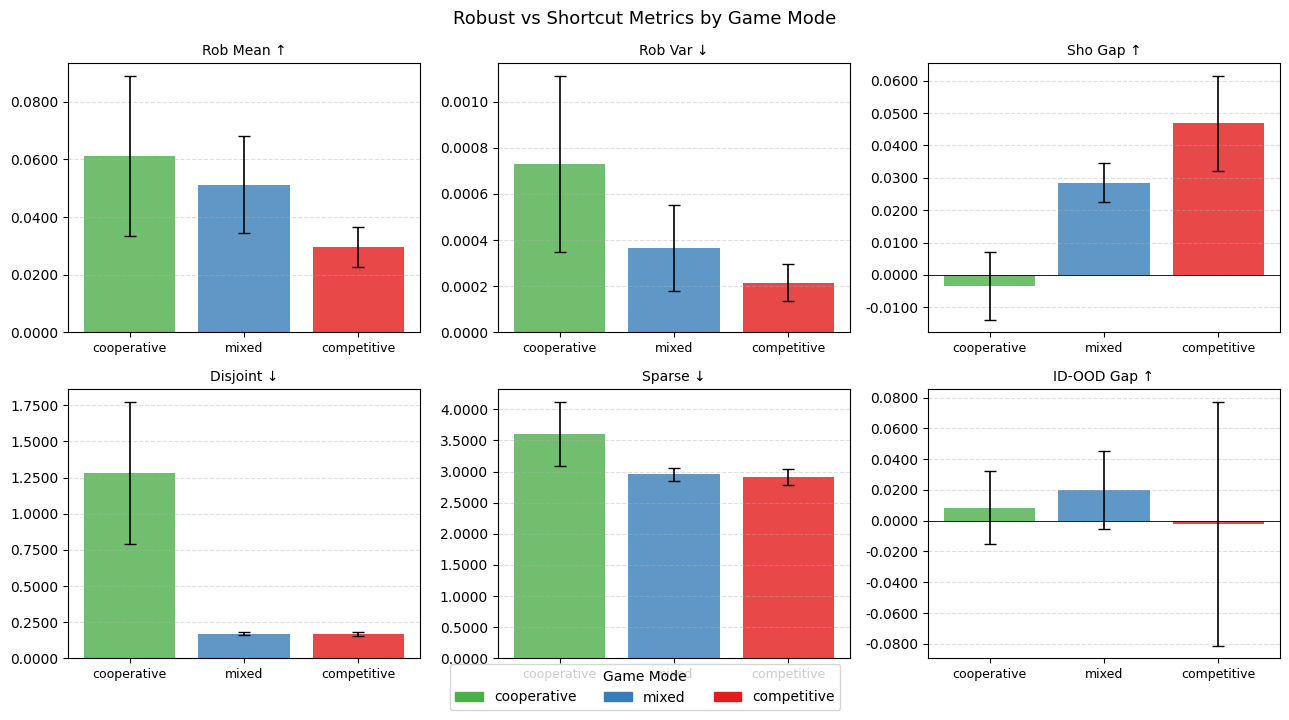

Saved to /Users/ssuresh/gambit/examples/out/plot_shift_metrics_by_mode.png


In [3]:
signal_metrics = ['rob_mean', 'rob_var', 'sho_gap', 'disjoint', 'sparse', 'id_ood_gap']
signal_labels  = ['Rob Mean ↑', 'Rob Var ↓', 'Sho Gap ↑', 'Disjoint ↓', 'Sparse ↓', 'ID-OOD Gap ↑']

# Color per game mode
mode_colors = {
    'cooperative': '#4daf4a',
    'mixed':       '#377eb8',
    'competitive': '#e41a1c',
}
modes = df['game_mode'].tolist()

n_metrics = len(signal_metrics)
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()

x = np.arange(len(modes))
for ax, key, label in zip(axes, signal_metrics, signal_labels):
    mus  = [df[df['game_mode'] == m][f'{key}_mean'].values[0]  if not df[df['game_mode'] == m].empty else 0 for m in modes]
    stds = [df[df['game_mode'] == m][f'{key}_std'].values[0]   if not df[df['game_mode'] == m].empty else 0 for m in modes]
    bar_colors = [mode_colors.get(m, '#999999') for m in modes]
    errs = stds if n_seeds > 1 else None
    ax.bar(x, mus, color=bar_colors, alpha=0.8,
           yerr=errs, capsize=4, error_kw={'linewidth': 1.2})
    ax.set_xticks(x)
    ax.set_xticklabels(modes, fontsize=9)
    ax.set_title(label, fontsize=10)
    ax.axhline(0, color='black', linewidth=0.6)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))

# Legend
handles = [plt.Rectangle((0, 0), 1, 1, color=mode_colors.get(m, '#999')) for m in modes]
fig.legend(handles, modes, loc='lower center', ncol=len(modes), fontsize=10,
           title='Game Mode', bbox_to_anchor=(0.5, -0.03))

fig.suptitle('Robust vs Shortcut Metrics by Game Mode', fontsize=13)
plt.tight_layout()
out = REPO / 'examples' / 'out' / 'plot_shift_metrics_by_mode.png'
plt.savefig(out, dpi=120, bbox_inches='tight')
plt.show()
print('Saved to', out)

## 3. Rob Mean vs Sho Gap — Tradeoff Scatter

Shows how game mode shifts the tradeoff between robust sufficiency and shortcut ID-OOD gap.  
Ideal: high Rob Mean (right) + high Sho Gap (top).

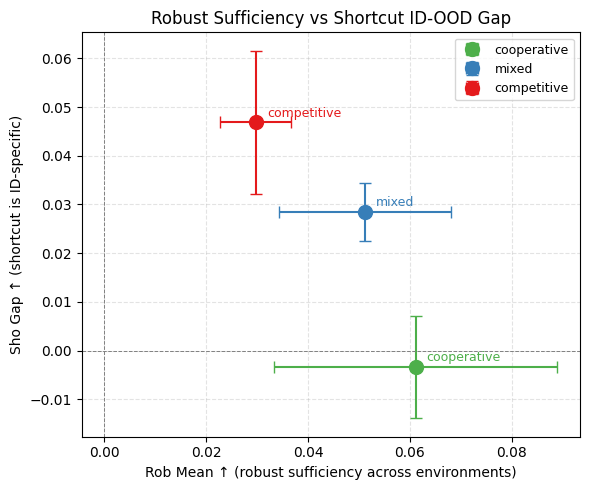

Saved to /Users/ssuresh/gambit/examples/out/plot_shift_tradeoff.png


In [4]:
fig, ax = plt.subplots(figsize=(6, 5))

for _, row in df.iterrows():
    mode = row['game_mode']
    rob  = row.get('rob_mean_mean', 0)
    gap  = row.get('sho_gap_mean', 0)
    rob_std = row.get('rob_mean_std', 0) if n_seeds > 1 else 0
    gap_std = row.get('sho_gap_std', 0) if n_seeds > 1 else 0
    color = mode_colors.get(mode, 'gray')
    ax.errorbar(rob, gap, xerr=rob_std, yerr=gap_std,
                fmt='o', color=color, markersize=10, capsize=4,
                label=mode, linewidth=1.5)
    ax.annotate(mode, (rob, gap), textcoords='offset points',
                xytext=(8, 4), fontsize=9, color=color)

ax.axhline(0, color='gray', linewidth=0.7, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.7, linestyle='--')
ax.set_xlabel('Rob Mean ↑ (robust sufficiency across environments)')
ax.set_ylabel('Sho Gap ↑ (shortcut is ID-specific)')
ax.set_title('Robust Sufficiency vs Shortcut ID-OOD Gap')
ax.grid(linestyle='--', alpha=0.35)
ax.legend(fontsize=9)

plt.tight_layout()
out = REPO / 'examples' / 'out' / 'plot_shift_tradeoff.png'
plt.savefig(out, dpi=120, bbox_inches='tight')
plt.show()
print('Saved to', out)

## 4. Per-Batch Distributions — Rob Mean and Sho Gap

Box plots across batches for each game mode.  
Shows whether the metrics are stable or noisy across batches.

/var/folders/sx/1v4_rhcd3h998mhd7mxbvfl00000gn/T/ipykernel_3726/233155013.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=pb_modes, patch_artist=True,
/var/folders/sx/1v4_rhcd3h998mhd7mxbvfl00000gn/T/ipykernel_3726/233155013.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=pb_modes, patch_artist=True,
/var/folders/sx/1v4_rhcd3h998mhd7mxbvfl00000gn/T/ipykernel_3726/233155013.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=pb_modes, patch_artist=True,
/var/folders/sx/1v4_rhcd3h998mhd7mxbvfl00000gn/T/ipykernel_3726/233155

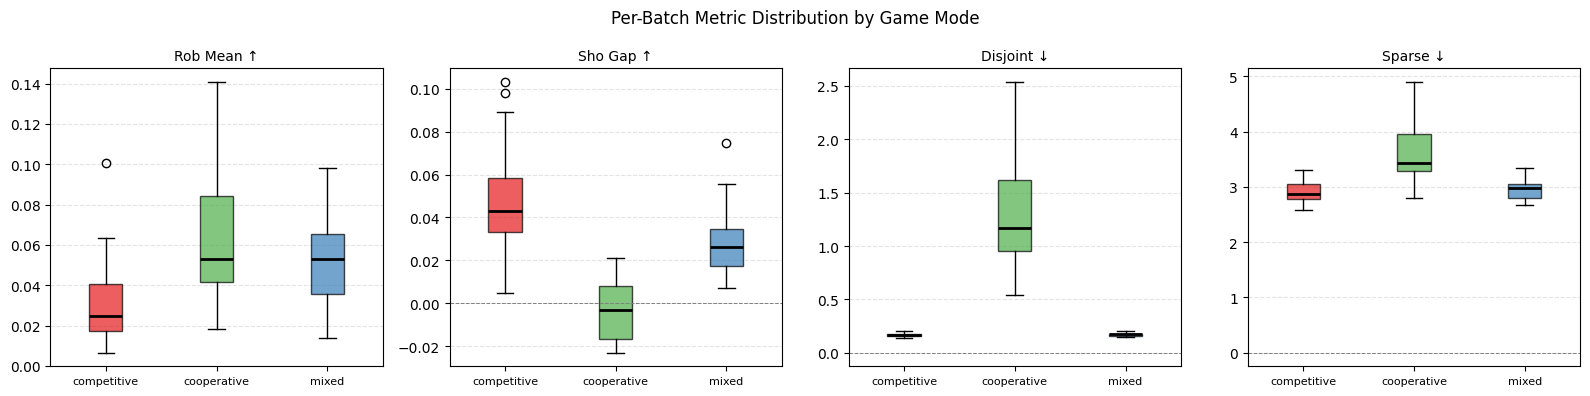

Saved to /Users/ssuresh/gambit/examples/out/plot_shift_per_batch.png


In [5]:
import glob

pb_frames = []
for fpath in sorted(glob.glob(str(REPO / 'scripts' / 'out' / 'shift_*_per_batch.csv'))):
    fname = Path(fpath).stem  # e.g. shift_mixed_seed0_per_batch
    parts = fname.split('_')
    # parts: ['shift', mode, 'seed0', 'per', 'batch'] — mode may be two words e.g. 'shift'
    # reconstruct: everything between 'shift' and the seed tag
    seed_idx = next((i for i, p in enumerate(parts) if p.startswith('seed')), None)
    if seed_idx is None:
        continue
    mode_name = '_'.join(parts[1:seed_idx])
    seed_tag  = parts[seed_idx]
    tmp = pd.read_csv(fpath)
    tmp['game_mode'] = mode_name
    tmp['seed'] = seed_tag
    pb_frames.append(tmp)

if not pb_frames:
    print('No per-batch shift CSVs found.')
else:
    pb = pd.concat(pb_frames, ignore_index=True)
    plot_metrics = ['rob_mean', 'sho_gap', 'disjoint', 'sparse']
    plot_labels  = ['Rob Mean ↑', 'Sho Gap ↑', 'Disjoint ↓', 'Sparse ↓']
    pb_modes = pb['game_mode'].unique().tolist()

    fig, axes = plt.subplots(1, len(plot_metrics), figsize=(4 * len(plot_metrics), 4))
    if len(plot_metrics) == 1:
        axes = [axes]

    for ax, key, label in zip(axes, plot_metrics, plot_labels):
        data   = [pb[pb['game_mode'] == m][key].dropna().values for m in pb_modes]
        colors = [mode_colors.get(m, 'gray') for m in pb_modes]
        bp = ax.boxplot(data, labels=pb_modes, patch_artist=True,
                        medianprops={'color': 'black', 'linewidth': 2})
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        ax.set_title(label, fontsize=10)
        ax.axhline(0, color='gray', linewidth=0.7, linestyle='--')
        ax.grid(axis='y', linestyle='--', alpha=0.35)
        ax.tick_params(axis='x', labelsize=8)

    fig.suptitle('Per-Batch Metric Distribution by Game Mode', fontsize=12)
    plt.tight_layout()
    out = REPO / 'examples' / 'out' / 'plot_shift_per_batch.png'
    plt.savefig(out, dpi=120, bbox_inches='tight')
    plt.show()
    print('Saved to', out)

## 5. Mask Visualization

The robust and shortcut masks overlaid on the input image.  
Green = robust evidence regions, Red = shortcut evidence regions.

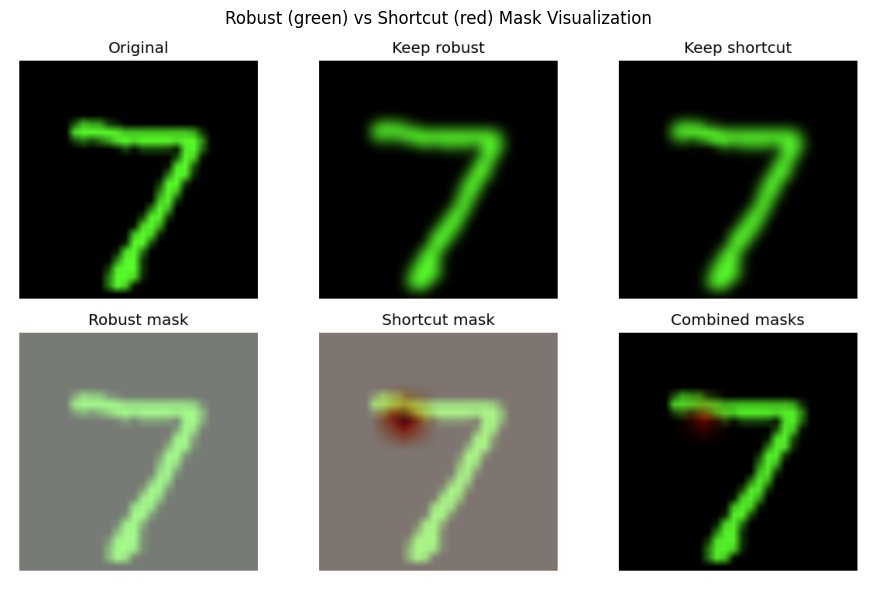

In [6]:
from PIL import Image

if MASK_PNG.exists():
    img = Image.open(MASK_PNG)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title('Robust (green) vs Shortcut (red) Mask Visualization', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print(f'Mask PNG not found at {MASK_PNG}')
    print('Run: PYTHONPATH=. python scripts/eval_robust_shortcut.py --game_mode mixed')